<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Updated_code_on_K_means_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the file:


Saving Retail_Store_Segmentation.csv to Retail_Store_Segmentation.csv
Data Shape: (5000, 10)


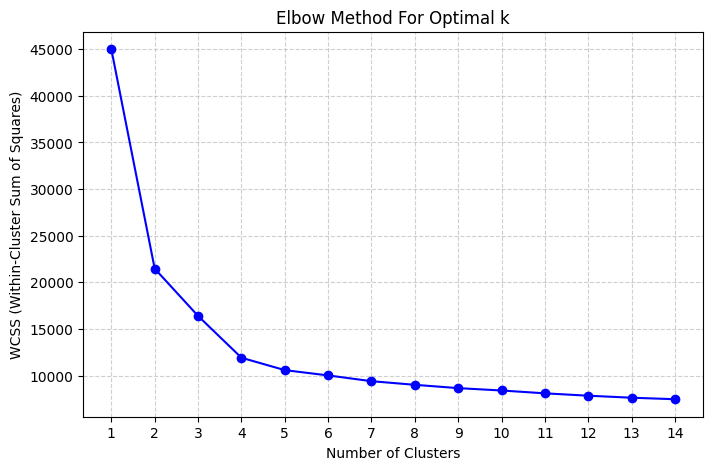

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
# If running locally, ensure 'Retail_Store_Segmentation.csv' is in your directory.
csv_filename = "Retail_Store_Segmentation.csv"

if not os.path.exists(csv_filename):
    try:
        from google.colab import files

        print("Please upload the file:")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"'{csv_filename}' not found. Please place it in the working directory."
        )

df = pd.read_csv(csv_filename)

# 2. Inspect the data (Optional but good practice)
print(f"Data Shape: {df.shape}")

# 3. Feature Selection & Preprocessing
# Drop the identifier column 'Store_ID'
features = df.drop(columns=["Store_ID"])

# Optional Enhancement: If 'City_Tier' should be categorical rather than continuous:
# features = pd.get_dummies(features, columns=['City_Tier'], drop_first=True)

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 5. Elbow Method using KMeans
wcss = []
cluster_range = range(1, 15)

for i in cluster_range:
    kmeans = KMeans(
        n_clusters=i,
        n_init=10,  # Explicitly set to avoid current/future warnings
        random_state=42,
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 6. Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker="o", linestyle="-", color="b")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method For Optimal k")
plt.xticks(cluster_range)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Based on your graph, 3 to 5 clusters is indeed the correct choice!